In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score


In [3]:
X , y = make_regression(
    n_samples=300,
    n_features=1,
    noise=20,
    random_state=42)


In [4]:
X_b = np.c_[np.ones((300,1)),X]

In [5]:
def total_cost(X_b , y , theta):
    m=len(y)
    y_pred = X_b @ theta
    error=y_pred - y
    cost=( 1 / (2 * m))* np.sum(error ** 2)
    return cost
    

In [6]:
def gradient_descent(X_b , y , theta , alpha , n_iterations):
    m=len(y)
    cost_history=[]
    for i in range(n_iterations):
        y_pred= X_b @ theta
        error=y_pred - y
        gradients = (1/m) * X_b.T @ error
        theta = theta - alpha* gradients
        cost_history.append(total_cost(X_b,y,theta))
    return theta , cost_history


In [12]:
theta=np.zeros(2)
alpha=0.01
n_iterations=1000
theta_final , cost_history = gradient_descent(X_b , y , theta , alpha , n_iterations)
print("Intercept:" , theta_final[0])
print("Slope:" , theta_final[1])

Intercept: 0.7476686822409007
Slope: 27.986544675409018


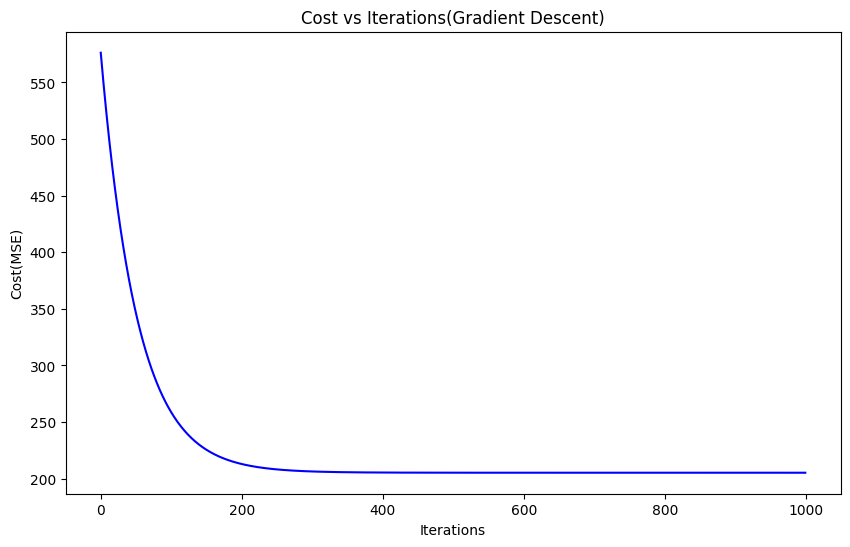

In [8]:
# plot cost curve
plt.figure(figsize=(10,6))
plt.plot(range(n_iterations),cost_history,color="blue")
plt.title("Cost vs Iterations(Gradient Descent)")
plt.xlabel("Iterations")
plt.ylabel("Cost(MSE)")
plt.savefig("plots/01_cost_curve.png")

In [ ]:
y_pred_scratch = X_b @ theta_final



array([-1.66795392e+01, -6.32084117e+00, -4.75268213e+01, -1.82838736e+01,
       -1.00359275e+01,  1.02953337e+01, -1.02260837e+01,  2.37542921e+01,
        1.12621581e+01,  3.18381535e+00,  7.51935661e+00,  8.02089011e+00,
       -1.49888164e+01,  3.03328671e+01,  5.01566327e+01, -7.67918335e+00,
        2.24269992e+01,  9.18693685e+00, -2.48892714e+00,  2.80498060e+01,
        3.31573575e+00, -4.85937334e+01,  2.77092378e+01,  1.97672614e+01,
        1.88742329e+01, -3.92770469e+01,  2.45250957e+01, -3.25927999e+01,
        3.31727556e+01,  4.21088164e+01, -1.26627625e+01, -1.40784889e+01,
       -5.07695398e+00, -8.42246262e+00, -1.74883736e+01,  2.88330870e+01,
        2.59243608e+01, -6.11989679e+00,  3.12236332e+01, -1.17487420e+01,
        6.20509529e+01, -1.00294538e+01, -3.41734711e+01, -2.39884469e+01,
        2.68109813e+01,  3.69927999e-01,  1.83688044e+01,  5.35354947e+01,
       -1.28043698e+01,  2.35152046e+01, -2.22203937e+01,  1.48805177e+01,
        6.55269641e+01, -

In [24]:
# polynomial regression
X= 6* np.random.rand(200,1) - 3
Y= 0.8 * X ** 2 + 0.9 * X + 2 + np.random.rand(200,1)


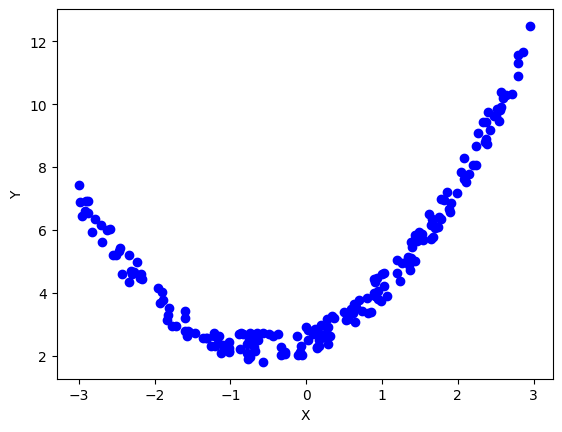

In [9]:
plt.scatter(X,Y,color="blue")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()


In [25]:
# train test split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [26]:
lr=LinearRegression()

In [27]:
lr.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
y_pred=lr.predict(X_test)
r2_score(Y_test,y_pred)

0.49464419221615263

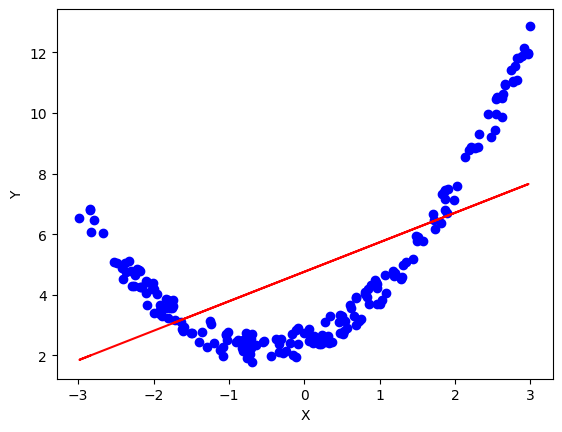

In [32]:
plt.plot(X_train,lr.predict(X_train),color="red")
plt.scatter(X,Y,color="blue")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [ ]:
# applying polynomial linear regression (degree=2)
poly=PolynomialFeatures(degree=2,)

X_train_trans=poly.fit_transform(X_train)
X_test_trans=poly.transform(X_test)
print(X_train[0])
print(X_train_trans[0])


[-1.73667035]
[ 1.         -1.73667035  3.01602389]


In [39]:
lr=LinearRegression()
lr.fit(X_train_trans,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
y_pred=lr.predict(X_test_trans)

In [43]:
r2_score(Y_test,y_pred)

0.9909017076952282

In [44]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.91824733 0.81675187]]
[2.47778179]


In [47]:
X_new=np.linspace(-3,3,200).reshape(200,1)
X_new_poly=poly.transform(X_new)
Y_new=lr.predict(X_new_poly)


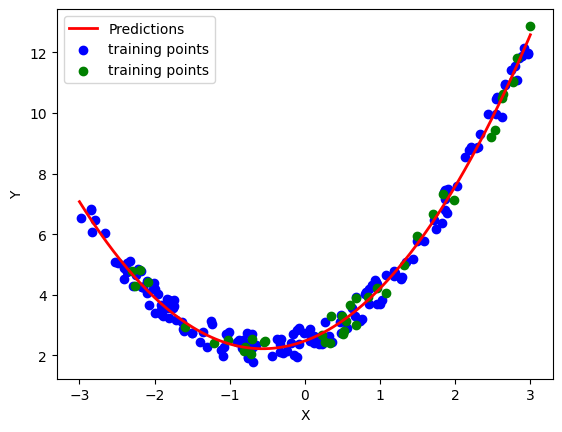

In [49]:
plt.plot(X_new,Y_new,color="red",linewidth=2,label="Predictions")
plt.scatter(X_train,Y_train,color="blue",label="training points")
plt.scatter(X_test,Y_test,color="green",label="training points")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()